#***MODELOS ESTADÍSTICOS: PROBABILIDAD***

![nombre alternativo](https://semur.edu.uy/recursos/probabilidadyestadistica/Unidad_Probabilidad_completa_v_5/dados_rojos.gif)

###***Autor:*** *Solis Villafuerte Sebastian*

----

##### ***1-. PROBABILIDAD LAPLACIANA (CLÁSICA)***

La probabilidad de un evento $A$ es el cociente entre el número de casos favorables y el número total de casos posibles en el espacio muestral $\Omega$, bajo la premisa de que todos los resultados son igualmente probables (equiprobables).

$$P(A) = \frac{|A|}{|\Omega|}$$

**Ejemplo:** Si lanzamos una moneda 3 veces de forma independiente, el espacio muestral es $\Omega = \{A, S\}^3 = 2^3 = 8$; con base en esto, vamos a calcular la probabilidad de que ocurran los siguientes eventos.

- Evento $A$: Todos los resultados son águila.

- Evento $S$: Todos los resultados son soles.

- Evento $E$: Por lo menos un resultado es sol.

**Paso 1:** Importamos las herramientas necesarias

In [1]:
import itertools
import random
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
from fractions import Fraction

**Paso 2:** Definimos el espacio muestral ($2^3 = 8$ resultados)

In [2]:
Omega = set(product({"A", "S"}, repeat=3))

In [3]:
print(f"Espacio muestral (Ω): {Omega}")

Espacio muestral (Ω): {('A', 'S', 'S'), ('A', 'A', 'A'), ('A', 'S', 'A'), ('A', 'A', 'S'), ('S', 'A', 'A'), ('S', 'S', 'S'), ('S', 'A', 'S'), ('S', 'S', 'A')}


**Paso 3:** Definimos los 3 eventos antes mencionados

In [4]:
A = {resultado for resultado in Omega if all(r == "A" for r in resultado)}
print(f"Evento A: {A}")

Evento A: {('A', 'A', 'A')}


In [5]:
S = {resultado for resultado in Omega if all(r == "S" for r in resultado)}
print(f"Evento S: {S}")

Evento S: {('S', 'S', 'S')}


In [6]:
E = {resultado for resultado in Omega if resultado.count("S") >= 1}
print(f"Evento E: {E}")

Evento E: {('A', 'S', 'S'), ('A', 'S', 'A'), ('A', 'A', 'S'), ('S', 'A', 'A'), ('S', 'S', 'S'), ('S', 'A', 'S'), ('S', 'S', 'A')}


**Paso 4:** Aplicamos la fórmula de Laplace

In [7]:
def probabilidad_laplaciana(evento, espacio_muestral):
    return Fraction(len(evento), len(espacio_muestral))

**Paso 5:** Y calculamos la probabilidad de que cada evento ocurra

In [8]:
P_A = probabilidad_laplaciana(A, Omega)
print(f"P(A) = {len(A)}/{len(Omega)} = {float(P_A):.3f}")

P(A) = 1/8 = 0.125


In [9]:
P_S = probabilidad_laplaciana(S, Omega)
print(f"P(S) = {len(S)}/{len(Omega)} = {float(P_S):.3f}")

P(S) = 1/8 = 0.125


In [10]:
P_E = probabilidad_laplaciana(E, Omega)
print(f"P(E) = {len(E)}/{len(Omega)} = {float(P_E):.3f}")

P(E) = 7/8 = 0.875


----

##### ***2-. PROBABILIDAD CONDICIONAL***

La probabilidad condicional de un evento $A$ dado que ya ocurrió el evento $B$ se define como la probabilidad de que ocurra la intersección de ambos, pero restringiendo nuestro "universo" únicamente a los casos del evento $B$.

$$P(A|B) = \frac{P(A \cap B)}{P(B)} = \frac{|A \cap B|}{|B|} $$

Donde: $P(B) > 0$

**Ejemplo:** Calcularemos la probabilidad de que el primer lanzamiento sea águila (evento $B$) sabiendo que obtuvimos exactamente dos águilas (evento $C$).

**Paso 1:** Definimos los eventos antes mencionados

In [11]:
B = {om for om in Omega if om[0] == "A"}
print(f"Evento B: {B}")

Evento B: {('A', 'A', 'A'), ('A', 'S', 'S'), ('A', 'A', 'S'), ('A', 'S', 'A')}


In [12]:
C = {om for om in Omega if om.count("A") == 2}
print(f"Evento C: {C}")

Evento C: {('S', 'A', 'A'), ('A', 'A', 'S'), ('A', 'S', 'A')}


**Paso 2:** Aplicamos la función de probabilidad condicional

In [13]:
def prob_cond(E, F):
    return len(E & F) / len(F)

In [14]:
P_B_dado_C = prob_cond(B, C)
print(f"P(B|C) = {len(B & C)}/{len(C)} = {P_B_dado_C:.3f}")

P(B|C) = 2/3 = 0.667


---

##### ***3-. INDEPENDENCIA DE EVENTOS***

Dos eventos $A$ y $B$ son independientes si la ocurrencia de uno no afecta la probabilidad de ocurrencia del otro. Matemáticamente, deben cumplir que la probabilidad de su intersección sea igual al producto de sus probabilidades individuales.

$$P(A \cap B) = P(A) \cdot P(B)$$

**Ejemplo:** Vamos a comprobar si el evento $B$ (primer águila) y el evento $C$ (dos águilas exactas) son independientes.

**Paso 1:** Definimos la función de verificación

In [15]:
def prob(E):
    return len(E) / len(Omega)

In [16]:
def es_independiente(E, F):
    return prob(E & F) == prob(E) * prob(F)

**Paso 2:** Ejecutamos el cálculo

In [17]:
p_interseccion = prob(B & C)
p_producto = prob(B) * prob(C)
resultado = es_independiente(B, C)

In [18]:
print(f"¿Son independientes? = {resultado}")

¿Son independientes? = False


In [19]:
print(f"P(B ∩ C) = {p_interseccion} | P(B) * P(C) = {p_producto}")

P(B ∩ C) = 0.25 | P(B) * P(C) = 0.1875


**Nota:** Como $0.25 \neq 0.1875$, los eventos no son independientes. El hecho de saber que salieron dos águilas altera la probabilidad de que la primera haya sido águila.

---

##### ***4-. PROBABILIDAD FRECUENTISTA***

A diferencia de la probabilidad clásica, la probabilidad frecuentista se basa en la experimentación. Fue Jacob Bernoulli quien, en 1713, formuló la base de este concepto a través de la Ley de los Grandes Números. Bajo este enfoque, la probabilidad se define como el límite de la frecuencia relativa de un evento a medida que el número de ensayos crece.

Esto se expresa mediante la siguiente fórmula, en donde la frecuencia relativa de un evento $A$ se obtiene al dividir $n(A)$, que es el número de veces que ocurre dicho evento, entre $n$, el número total de veces que se realizó el experimento.

$$f_{n}(A) = \frac{n(A)}{n}$$

Así, a medida que el número de repeticiones aumenta, este cociente tiende a estabilizarse, proporcionando una estimación cada vez más precisa de la probabilidad real.

**Ejemplo:** Consideremos la simulación de un lanzamiento de una moneda donde la probabilidad de obtener "sol" no es necesariamente $0.5$ (50%).

**Paso 1:** Primero, como una simple prueba para entender el concepto, definimos la función del experimento para que genere un número aleatorio entre 0 y 1; si este es menor que $p$, se considera "sol".

In [20]:
def volado(p):
    return "sol" if random.random() < p else "águila"

**Paso 2:** Después, realizamos una serie de ensayos, simulando 10 lanzamientos con una probabilidad de obtener "sol" del 40% (p = 0.4).

In [21]:
vol = [volado(0.4) for i in range(10)]

In [22]:
print(f"Resultados: {vol}")

Resultados: ['sol', 'sol', 'sol', 'águila', 'águila', 'águila', 'águila', 'águila', 'águila', 'águila']


In [23]:
print(f"Soles obtenidos: {vol.count('sol')}")

Soles obtenidos: 3


**Paso 3:** Ahora sí, se aplica la Ley de los Grandes Números para estimar la probabilidad real; por ende, el experimento se repite un gran número de veces (1,000) y se calcula la frecuencia relativa promedio.

In [24]:
p_frecuencias = []
N_lanzamientos = 1000

La moneda está cargada al 63% para sol

In [25]:
prob_real = 0.63

In [26]:
for i in range(1000):
    resultados = [volado(prob_real) for j in range(N_lanzamientos)]
    n_soles = resultados.count("sol")
    p_frecuencias.append(n_soles / N_lanzamientos)

El promedio de todas las frecuencias se acercará al valor real

In [27]:
p_soles_prom = sum(p_frecuencias) / len(p_frecuencias)
print(f"La probabilidad frecuentista promedio es de: {p_soles_prom:.4f}")

La probabilidad frecuentista promedio es de: 0.6296


Con esto, observamos que la probabilidad frecuentista de obtener "sol" se estabiliza y converge hacia el valor de la probabilidad real programada ($p = 0.63$).

**Nota:** Tomemos en cuenta que, a medida que aumenta el valor de $n$, la probabilidad obtenida mediante la frecuencia relativa se estabiliza y se aproxima cada vez más al valor teórico $p$.

---

#***EJERCICIOS***

![nombre alternativo](https://www.gifss.com/economia/juego/images/ruleta-05.gif)

##### ***1-. LANZAMIENTO DE 3 DADOS***

Si lanzamos un dado tradicional tres veces seguidas, el espacio muestral crece considerablemente. Usando Python:

**a)** Define el nuevo espacio muestral $\Omega$ usando `itertools.product` y calcula su cardinalidad.

In [28]:
dado = range(1, 7)
omega = list(itertools.product(dado, repeat=3))
cardinalidad_omega = len(omega)

In [29]:
print(f"La cardinalidad de Ω es de: {cardinalidad_omega}")

La cardinalidad de Ω es de: 216


**b)** Sea el evento $A$: "La suma de los tres dados es exactamente 10". Construye el conjunto para $A$ y calcula ${P}(A)$.

In [30]:
evento_a = [resultado for resultado in omega if sum(resultado) == 10]
probabilidad_a = len(evento_a) / cardinalidad_omega

In [31]:
print(f"La cantidad de resultados posibles en A es de: {len(evento_a)}")

La cantidad de resultados posibles en A es de: 27


In [32]:
print(f"La P(A) es de {len(evento_a)}/{cardinalidad_omega} = {probabilidad_a:.3f}")

La P(A) es de 27/216 = 0.125


**c)** Sea el evento $B$: "Los tres dados muestran números distintos". Construye el conjunto para $B$ y calcula ${P}(B)$.

In [33]:
evento_b = [resultado for resultado in omega if len(set(resultado)) == 3]
probabilidad_b = len(evento_b) / cardinalidad_omega

In [34]:
print(f"La cantidad de resultados posibles en B es de: {len(evento_b)}")

La cantidad de resultados posibles en B es de: 120


In [35]:
print(f"La P(B) es de {len(evento_b)}/{cardinalidad_omega} = {probabilidad_b:.4f}")

La P(B) es de 120/216 = 0.5556


##### ***2-. CONDICIONALES E INDEPENDENCIA***

Retomando el experimento original de lanzar dos dados ($\Omega$ con 36 elementos), define los siguientes eventos mediante comprensión de conjuntos:

- $P$: La suma de ambos dados es un número par.

- $D$: Se obtiene un "doble" (ambos dados muestran exactamente el mismo número).

Por ende, responde lo siguiente mediante código:

In [36]:
dado = range(1, 7)
omega = list(itertools.product(dado, repeat=2))
n_omega = len(omega)

**a)** Calcula ${P}(P)$ y ${P}(D)$.

In [37]:
evento_p = [res for res in omega if sum(res) % 2 == 0]
prob_p = len(evento_p) / n_omega

In [38]:
print(f"La P(P) es de {len(evento_p)}/36 = {prob_p:.1f}")

La P(P) es de 18/36 = 0.5


In [39]:
evento_d = [res for res in omega if res[0] == res[1]]
prob_d = len(evento_d) / n_omega

In [40]:
print(f"La P(D) es de {len(evento_d)}/36 = {prob_d:.3f}")

La P(D) es de 6/36 = 0.167


**b)** Calcula la probabilidad de obtener un doble dado que sabemos que la suma fue par. Es decir, encuentra ${P}(D \mid P)$.

In [41]:
interseccion_dp = [res for res in evento_p if res in evento_d]
prob_d_dado_p = len(interseccion_dp) / len(evento_p)

In [42]:
print(f"La P(D | P) es de {len(interseccion_dp)}/{len(evento_p)} = {prob_d_dado_p:.3f}")

La P(D | P) es de 6/18 = 0.333


**c)** Utiliza una función para comprobar matemáticamente si los eventos $P$ y $D$ son independientes o no.

In [43]:
def es_independiente(p_p, p_d, p_condicional):
    if round(p_condicional, 4) == round(p_d, 4):
        return "son independientes"
    else:
        return "son dependientes"

In [44]:
print(f"Los eventos {es_independiente(prob_p, prob_d, prob_d_dado_p)}")

Los eventos son dependientes


##### ***3-. EL ENCUENTRO***

Romeo y Julieta planean encontrarse en un lugar específico dentro de un intervalo de una hora $[0, 60 \text{ min}]$.

- Si Romeo llega primero, esperará como máximo 10 minutos.
- Si Julieta llega primero, esperará como máximo 10 minutos.

Sea $X$ el tiempo de llegada de Romeo e $Y$ el de Julieta. El evento $A$ ocurre si se encuentran, lo cual sucede cuando $|X - Y| \leq 10$. Por lo tanto, se desea calcular la probabilidad de $A$ mediante simulación.

Definimos el tamaño de la muestra para la simulación

In [45]:
muestra = 10000

Generamos tiempos de llegada aleatorios para Romeo $X$ y Julieta $Y$

In [46]:
x = np.random.uniform(0, 60, muestra)
y = np.random.uniform(0, 60, muestra)

**Condición de encuentro:** la diferencia absoluta debe ser ***< =*** 10

In [47]:
encuentro = np.where(abs(x - y) <= 10, 'r', 'b')

Calculamos la probabilidad aproximada

In [48]:
favorables = np.count_nonzero(encuentro == 'r')
probabilidad_A = favorables / muestra

In [49]:
print(f"La probabilidad estimada del evento A es: {probabilidad_A:.4f}")

La probabilidad estimada del evento A es: 0.3055


**Nota:** Aquí el espacio muestral es un cuadrado de $60 \times 60$. El área favorable corresponde a la región donde $|x - y| \leq 10$. La simulación nos muestra que la probabilidad suele rondar el $30\%$, lo cual coincide con el cálculo geométrico teórico de la región sombreada en el cuadrado.

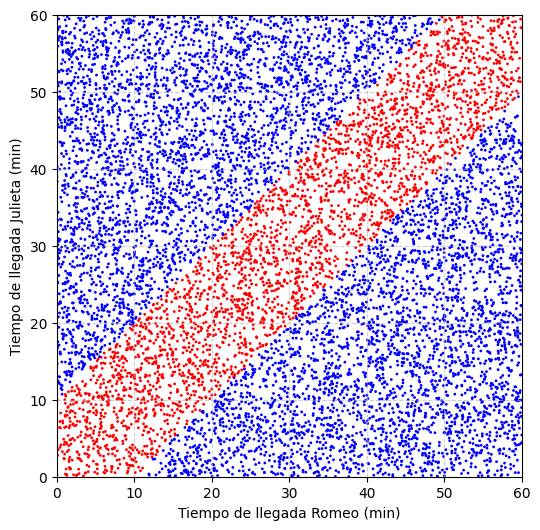

In [50]:
plt.figure(figsize=(6, 6))
plt.scatter(x, y, c=encuentro, s=1)
plt.xlabel('Tiempo de llegada Romeo (min)')
plt.ylabel('Tiempo de llegada Julieta (min)')
plt.xlim(0, 60)
plt.ylim(0, 60)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()